In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

lme = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'patients_lme_DTI.tsv'), sep = '\t')
lme['Week'] = lme['Week'].astype(int)
lme = lme.sort_values('Week')

# observed values
obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
obs = obs[obs.metric == 'FaMap']

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
obs = obs[~obs.subj_id.isin(controls)]

/localscratch/tmp/ipykernel_105305/4137450266.py:13: DtypeWarning: Columns (2,14) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


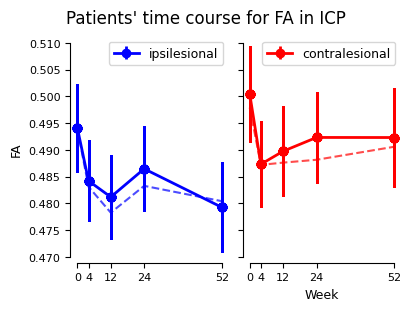

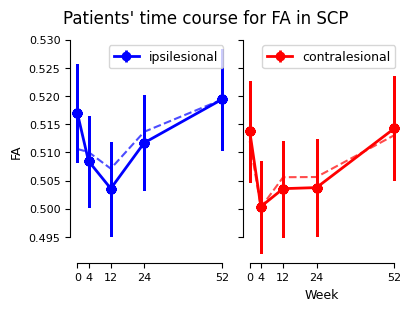

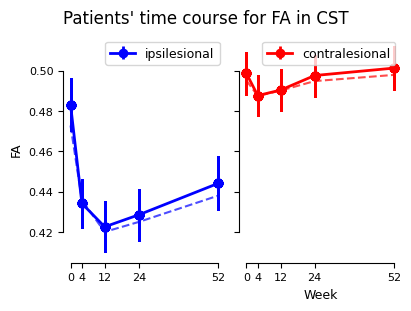

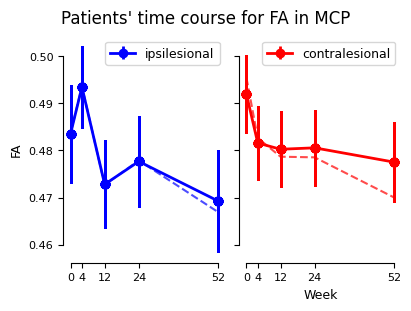

In [2]:
for r, region in enumerate(lme.region_bilat.unique()):
    fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

    lme_ipsi = lme[(lme.side == 'ipsilesional') & (lme.region_bilat == region)].sort_values('Week')
    lme_contra = lme[(lme.side == 'contralesional') & (lme.region_bilat == region)].sort_values('Week')

    obs_ipsi = obs[obs.Object == region + '_R'].groupby('week_num')['Mean'].mean().reset_index()
    obs_contra = obs[obs.Object == region + '_L'].groupby('week_num')['Mean'].mean().reset_index()

    axs[0].errorbar(x = lme_ipsi['Week'], y = lme_ipsi['beta'], yerr = lme_ipsi['se'], fmt = '-o', linewidth = 2, color = 'blue', label = 'ipsilesional')
    axs[1].errorbar(x = lme_contra['Week'], y = lme_contra['beta'], yerr = lme_contra['se'], fmt = '-o', linewidth = 2, color = 'red', label = 'contralesional')

    axs[0].plot(obs_ipsi['week_num'], obs_ipsi['Mean'], alpha = .7, linestyle = '--', color = 'blue')
    axs[1].plot(obs_contra['week_num'], obs_contra['Mean'], alpha = .7, linestyle = '--', color = 'red')

    for ax in axs:
        ax.legend()
        ax.set_xticks(gl.weeks)
        axs[0].set_ylabel("FA")
        axs[1].set_xlabel("Week")
    
    plt.suptitle(f"Patients' time course for FA in {region}")
    sns.despine(trim = True)
    plt.show()